## Описание проекта

# Определение стоимости автомобилей

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение для привлечения новых клиентов. В нём можно быстро узнать рыночную стоимость своего автомобиля. В вашем распоряжении исторические данные: технические характеристики, комплектации и цены автомобилей. Вам нужно построить модель для определения стоимости.

Заказчику важны:

- качество предсказания;
- скорость предсказания;
- время обучения.

### Цель исследования


Разработать модель для определения рыночной стоимости автомобиля с пробегом, удовлетворяющую требованиям заказчика по качеству предсказания, скорости обучения и скорости предсказания.

### Задачи исследования


1. Подготовка данных

    1. Загрузить данные из файла /datasets/autos.csv.

    2. Провести исследовательский анализ данных (EDA).

    3. Обработать пропущенные значения и аномалии в признаках.

    4. Удалить неинформативные признаки.
    

2. Предобработка данных

    1. Преобразовать категориальные признаки (кодирование, обработка редких категорий).

    2. Нормализовать/стандартизировать числовые признаки при необходимости.
    
    3. Разделить данные на обучающую, валидационную и тестовую выборки.
    

3. Обучение и сравнение моделей

    Обучить как минимум две модели:

        a. LightGBM (градиентный бустинг) с оптимизацией гиперпараметров.

        b. Более простую модель (например, линейную регрессию, случайный лес или дерево решений).

        Для каждой модели:

           a. Измерить время обучения.

           b. Измерить время предсказания.

           c. Оценить качество по метрике RMSE на валидационной выборке.


4. Анализ результатов

    1. Сравнить модели по трём критериям: качество (RMSE), время обучения, время предсказания.

    2. Выбрать лучшую модель, учитывая приоритеты заказчика.
    

5. Итоговая проверка модели

    1. Оценить качество лучшей модели на тестовой выборке.

    2. Убедиться, что значение RMSE < 2500.
    

### Исходные данные


Датасет:

    файл /datasets/autos.csv, содержащий информацию об автомобилях с пробегом.

Признаки:

    DateCrawled — дата скачивания анкеты.

    VehicleType — тип кузова.

    RegistrationYear — год регистрации.

    Gearbox — тип коробки передач.

    Power — мощность (л. с.).

    Model — модель автомобиля.

    Kilometer — пробег (км).

    RegistrationMonth — месяц регистрации.

    FuelType — тип топлива.

    Brand — марка автомобиля.

    Repaired — наличие ремонта в истории.

    DateCreated — дата создания анкеты.

    NumberOfPictures — количество фотографий.

    PostalCode — почтовый индекс владельца.

    LastSeen — дата последней активности.

Целевой признак:

    Price — цена автомобиля (евро).

Критерии оценки модели:

    Качество: RMSE (требуется < 2500).

Время обучения модели.

    Время предсказания модели.

Инструменты и ограничения:

    Обязательное использование LightGBM и хотя бы одной модели не из градиентного бустинга.

    Возможность оптимизации гиперпараметров (для бустинга — 2–3 параметра).


<div style="background: #B0E0E6; padding: 5px; border: 1px solid SteelBlue; border-radius: 5px;">
    <font color='4682B4'><u><b></b></u></font>
    <br />
    <font color='4682B4'>Исправила</font>
</div>

##  Подготовка данных 💜

### 🌸 Загрузка библиотек

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
import seaborn as sns
from scipy import stats
import lightgbm as lgb

import time

from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from catboost import Pool, CatBoostRegressor, cv
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')


In [ ]:
pip install --upgrade scikit-learn

Note: you may need to restart the kernel to use updated packages.


#### Вывод

Добавлены библиотеки:

    1. Основные

        a. matplotlib - для визуализации
        b. numpy - для вычислений
        c. pandas - для работы с таблицами

    2. Для машинного обучения и продвинутой формы:

        a. Scikit-learn и пакеты - для классических алгоритмов
        b. catboost - для градиентного бустинга
        c. lightgbm - для градиентного бустинга

    3. Вспомогательные:

        a. warning - обработка ошибок
        b. time - чтобы узнаь время обучения модели
        

### 🌸 Загрузка таблицы

In [ ]:
df = pd.read_csv("/datasets/autos.csv")
df.head(5)

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


<div class="alert alert-success">
<b>КОММЕНТАРИЙ V2</b>

<div class="alert alert-success">
<b>ОТЛИЧНО! 👍</b>

Отлично. Импортировали требуемые для анализа библиотеки и загрузили данные. Сейчас посмотрим на их состояние и если всё ОК, сможем приступать к построению моделей....
</div>

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   DateCrawled        354369 non-null  object
 1   Price              354369 non-null  int64 
 2   VehicleType        316879 non-null  object
 3   RegistrationYear   354369 non-null  int64 
 4   Gearbox            334536 non-null  object
 5   Power              354369 non-null  int64 
 6   Model              334664 non-null  object
 7   Kilometer          354369 non-null  int64 
 8   RegistrationMonth  354369 non-null  int64 
 9   FuelType           321474 non-null  object
 10  Brand              354369 non-null  object
 11  Repaired           283215 non-null  object
 12  DateCreated        354369 non-null  object
 13  NumberOfPictures   354369 non-null  int64 
 14  PostalCode         354369 non-null  int64 
 15  LastSeen           354369 non-null  object
dtypes: int64(7), object(

### 🌸 Предобработка данных. Исследование EDA

#### Первичный осмотр данных

Посмотрю на статистические показатели и сделаю выводы.

In [ ]:
display(df.describe())

,Price,RegistrationYear,Power,Kilometer,RegistrationMonth,NumberOfPictures,PostalCode
count,354369.000000,354369.000000,354369.000000,354369.000000,354369.000000,354369.0,354369.000000
mean,4416.656776,2004.234448,110.094337,128211.172535,5.714645,0.0,50508.689087
std,4514.158514,90.227958,189.850405,37905.341530,3.726421,0.0,25783.096248
min,0.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1050.000000,1999.000000,69.000000,125000.000000,3.000000,0.0,30165.000000
50%,2700.000000,2003.000000,105.000000,150000.000000,6.000000,0.0,49413.000000
75%,6400.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71083.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


In [ ]:
max_date = df['DateCrawled'].max()
print(f"Максимальная дата скачивания: {max_date}")

Максимальная дата скачивания: 2016-04-07 14:36:58


##### Вывод

    
    Цена(Price)

        1. min = 0 - это ошибка данных
        2. std = 4514 - большое стандартное отклонение относительно среднего
        3. max = 20000 - слишком большое число
        
    Год регистрации(RegistrationYear)
        
        1. min = 1000 - первая машина появилась в 1886 году. Нереалистичный год
        2. max = 9999 - ошибка данных
        3. 75% значений = 2008, но есть значения до 9999.
        4. база скачана на 2016 год - обьявления после 2016 не являются реальными
        
    Мощность(Power)
    
        1. min = 0 - ошибка данных
        2. max = 20000 - нереалистичное значение
        3. 50% автомобилей имеют мощность 105.
        
    Пробег(Kilometer)
    
        1. более-менее все адекватно.
        
    Месяц регистрации(RegistrationMonth)
    
        1. min = 0 - некорректное значение для месяца
        
    Количество фоторгафий(NumberOfPictures)
    
        1. Все значения = 0
        2. Признак неинформативен
        
    Почтовый индекс(PostalCode)
    
        1. Слишком много уникальных значений (354369 записей)

        2. Почтовый индекс вряд ли напрямую влияет на цену автомобиля

        3. Может использоваться для извлечения региона, но требует внешних данных


    
План действий:

    Цена

    1. Удалить записи с Price = 0.
    2. Рассмотреть логарифмическое преобразование.
    3. Проверить на выбросы (правило 1.5*IQR).
    
    Год регистрации
    
    1. Ограничить реалистичным диапазоном (например, 1950-2024).
    2. Удалить записи за пределами разумного диапазона.
    
    Мощность
    
    1. Удалить/исправить значения 0 и аномально высокие (>500-1000 л.с.)
    2. Проверить распределение в разумном диапазоне
    
    Пробег
    
    1.Проверить, не является ли это категориальным признаком

    Месяц регистрации
    
    1. Исправить 0 на модальное значение или удалить
    2. Преобразовать в категориальный признак (сезоны)
    
    Количество фотографий
    
    1. Удалить признак потому что он неинформативный
    
    Почтовый индекс
    
    1. Удалить признак, потому что он неинформативный
    

#### Проверка на выбросы и аномалии

##### Через графики

Теперь я дополнительно визуализирую, чтобы по графикам проследить аномальные значения и выбросы:

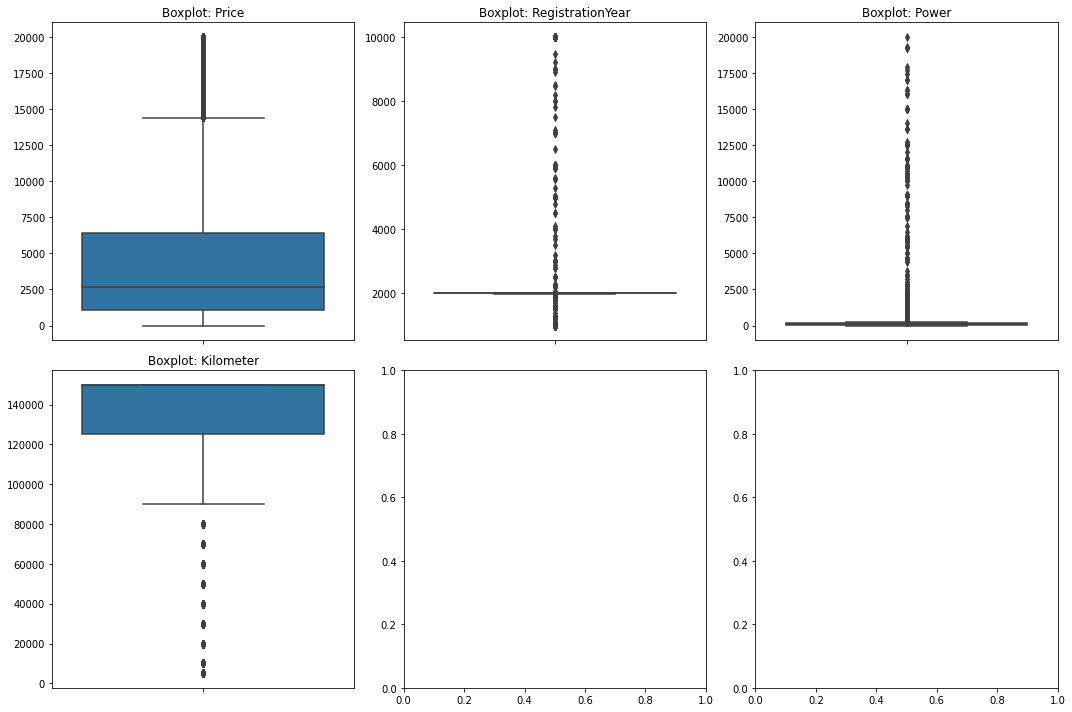

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
numeric_cols = ['Price', 'RegistrationYear', 'Power', 'Kilometer']

for idx, col in enumerate(numeric_cols):
    ax = axes[idx//3, idx%3]
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f'Boxplot: {col}')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

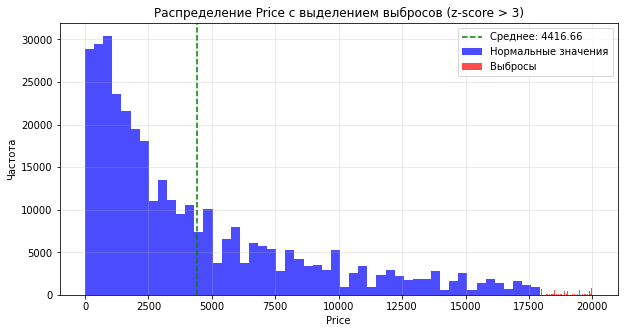

Выбросов в Price: 5484 (1.55%)


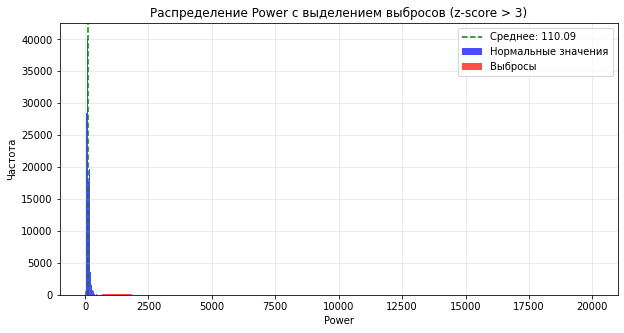

Выбросов в Power: 359 (0.10%)


In [ ]:
def plot_hist_with_outliers(col, df, threshold=3):
    mean = df[col].mean()
    std = df[col].std()

    outliers = df[abs(df[col] - mean) / std > threshold]
    normal = df[abs(df[col] - mean) / std <= threshold]

    plt.figure(figsize=(10,5))
    plt.hist(normal[col], bins=50, alpha=0.7, label='Нормальные значения', color='blue')
    plt.hist(outliers[col], bins=50, alpha=0.7, label='Выбросы', color='red')
    plt.axvline(mean, color='green', linestyle='--', label=f'Среднее: {mean:.2f}')
    plt.xlabel(col)
    plt.ylabel('Частота')
    plt.title(f'Распределение {col} с выделением выбросов (z-score > {threshold})')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    print(f"Выбросов в {col}: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

for col in ['Price', 'Power']:
    plot_hist_with_outliers(col, df)

#### Повторная проверка

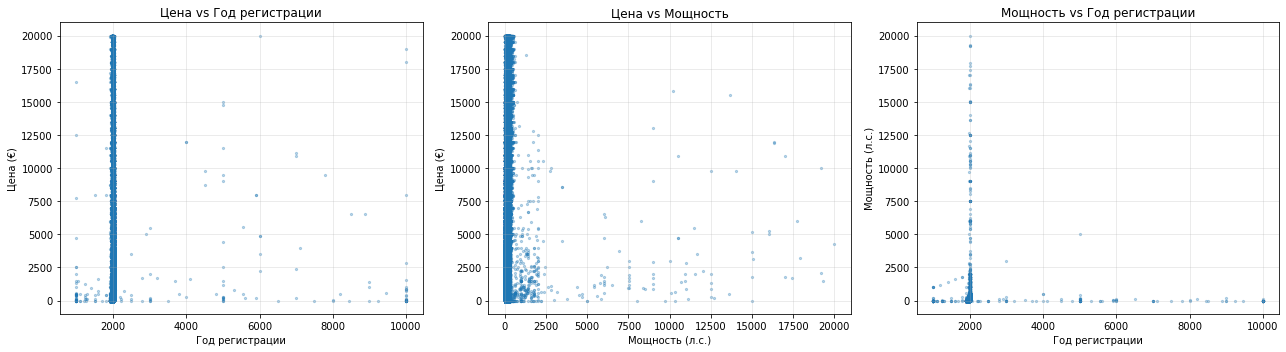

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df['RegistrationYear'], df['Price'], alpha=0.3, s=5)
axes[0].set_xlabel('Год регистрации')
axes[0].set_ylabel('Цена (€)')
axes[0].set_title('Цена vs Год регистрации')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df['Power'], df['Price'], alpha=0.3, s=5)
axes[1].set_xlabel('Мощность (л.с.)')
axes[1].set_ylabel('Цена (€)')
axes[1].set_title('Цена vs Мощность')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(df['RegistrationYear'], df['Power'], alpha=0.3, s=5)
axes[2].set_xlabel('Год регистрации')
axes[2].set_ylabel('Мощность (л.с.)')
axes[2].set_title('Мощность vs Год регистрации')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

##### Через статистический метод

In [ ]:

def detect_outliers_percentile(df, column, lower_percentile=0.01, upper_percentile=0.99):

    lower_bound = df[column].quantile(lower_percentile)
    upper_bound = df[column].quantile(upper_percentile)

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    return outliers, lower_bound, upper_bound

for col in ['Price', 'RegistrationYear', 'Power']:
    outliers, lower, upper = detect_outliers_percentile(df, col, 0.01, 0.99)

    print(f"\n{col} - выбросы за пределами 1%-99% перцентилей:")
    print(f"Нижняя граница (1%): {lower:.2f}")
    print(f"Верхняя граница (99%): {upper:.2f}")
    print(f"Выбросов: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")



Price - выбросы за пределами 1%-99% перцентилей:
Нижняя граница (1%): 0.00
Верхняя граница (99%): 18800.00
Выбросов: 3444 (0.97%)

RegistrationYear - выбросы за пределами 1%-99% перцентилей:
Нижняя граница (1%): 1980.00
Верхняя граница (99%): 2018.00
Выбросов: 3582 (1.01%)

Power - выбросы за пределами 1%-99% перцентилей:
Нижняя граница (1%): 0.00
Верхняя граница (99%): 300.00
Выбросов: 3505 (0.99%)


##### Вывод


1. Price (Цена)

    1% перцентиль: 0 - подтверждает наличие нулевых цен
    99% перцентиль: 18800 - более реалистично, чем 20000
    
Выбросы: 0.97%

2. RegistrationYear (Год регистрации)

    1% перцентиль: 1980 - это уже реалистичный год
    99% перцентиль: 2018 - разумная верхняя граница

Выбросы: 1.01% - в основном очень старые (>2018) или очень новые (<1980) авто

3. Power (Мощность)

    1% перцентиль: 0 - подтверждает нулевую мощность
    99% перцентиль: 300 - разумный предел (хотя >300 тоже бывают)

Выбросы: 0.99% - в основном нулевые и сверхвысокие значения


### Вывод


 1. Выбросы есть, но их немного
 2. Распределение смещено влево
 3. Наличие нулевых цен существует


### Корректировка статистических данных

#### Важность признаков

#### Вывод

    1. NumberOfPictures не является важным признаком для исследования, поэтому позже удалю.
    2. PostalCode нужно будет преобразовать в Region, а PostalCode я так же позже удалю.

#### Таблица Price

count    343597.000000
mean       4555.121974
std        4515.058553
min           1.000000
25%        1200.000000
50%        2890.000000
75%        6500.000000
max       20000.000000
Name: Price, dtype: float64

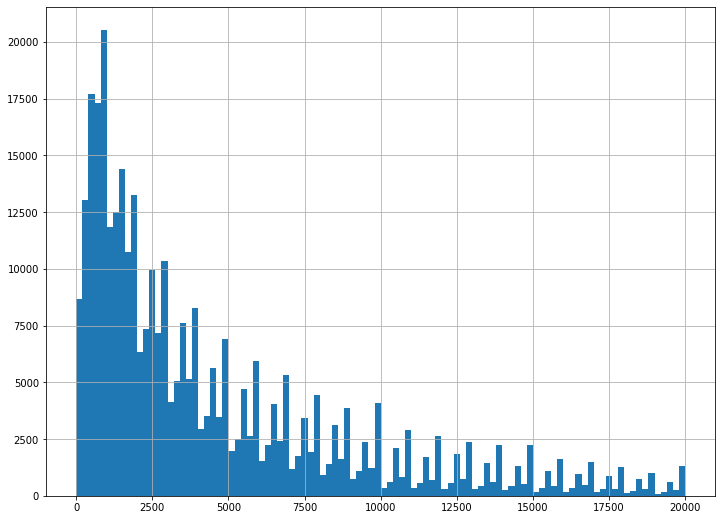

In [ ]:
df = df.query('Price > 0')
df['Price'].hist(bins=100, figsize=(12,9))
df['Price'].describe()

In [ ]:
df['Price'].quantile([0.2, 0.88])

0.20      990.0
0.88    10500.0
Name: Price, dtype: float64

In [ ]:
df = df.query('400 <= Price')

In [ ]:
df.describe()

,Price,RegistrationYear,Power,Kilometer,RegistrationMonth,NumberOfPictures,PostalCode
count,324350.000000,324350.000000,324350.000000,324350.000000,324350.000000,324350.0,324350.000000
mean,4812.138628,2004.086518,114.035829,128197.071065,5.882756,0.0,50884.917663
std,4518.349037,66.432307,187.892285,37176.791326,3.655396,0.0,25695.584914
min,400.000000,1000.000000,0.000000,5000.000000,0.000000,0.0,1067.000000
25%,1400.000000,1999.000000,75.000000,125000.000000,3.000000,0.0,30655.000000
50%,3100.000000,2004.000000,105.000000,150000.000000,6.000000,0.0,49699.000000
75%,6900.000000,2008.000000,143.000000,150000.000000,9.000000,0.0,71384.000000
max,20000.000000,9999.000000,20000.000000,150000.000000,12.000000,0.0,99998.000000


#### Таблица RegistrationYear

In [ ]:
df = df.loc[df['RegistrationYear'] <= 2016]
df = df.loc[df['RegistrationYear'] >= 1980]

#### Таблица Power

count    281714.000000
mean        122.667865
std          54.335780
min           1.000000
25%          80.000000
50%         115.000000
75%         150.000000
max         953.000000
Name: Power, dtype: float64

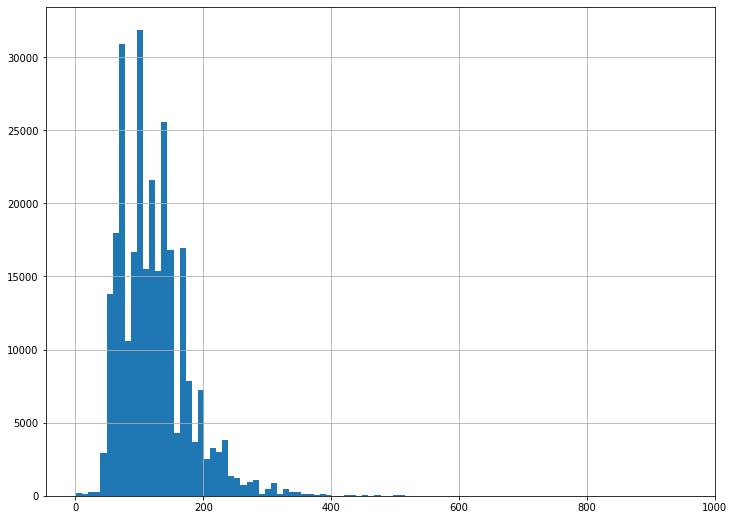

In [ ]:
df = df.loc[df['Power'] < 999]
df = df.loc[df['Power'] > 0]
df['Power'].hist(bins=100, figsize=(12,9))
df['Power'].describe()

In [ ]:
df['Power'].quantile([0.2, 0.88])

0.20     75.0
0.88    179.0
Name: Power, dtype: float64

In [ ]:
df = df.loc[df['Power'] > 70]

In [ ]:
df.describe()

,Price,RegistrationYear,Power,Kilometer,RegistrationMonth,NumberOfPictures,PostalCode
count,239276.000000,239276.000000,239276.000000,239276.000000,239276.000000,239276.0,239276.000000
mean,5545.550841,2003.500715,134.111353,129495.248165,6.079135,0.0,51809.630046
std,4731.073456,5.747737,50.928371,35878.311240,3.549336,0.0,25860.751164
min,400.000000,1980.000000,71.000000,5000.000000,0.000000,0.0,1067.000000
25%,1800.000000,2000.000000,101.000000,125000.000000,3.000000,0.0,31246.000000
50%,3990.000000,2004.000000,122.000000,150000.000000,6.000000,0.0,51069.000000
75%,7999.000000,2008.000000,156.000000,150000.000000,9.000000,0.0,72631.000000
max,20000.000000,2016.000000,953.000000,150000.000000,12.000000,0.0,99998.000000


#### Вывод

Чтобы понять,как отрегулировать мощность, я посмотрела,какие реальные показатели мощности по брендам существуют. Оттуда и числа.

#### Таблица RegistrationMonth

In [ ]:
median_RegistrationMonth = df[df['RegistrationMonth'] > 0]['RegistrationMonth'].median()
df.loc[df['RegistrationMonth'] == 0, 'RegistrationMonth'] = median_RegistrationMonth
df['RegistrationMonth'] = df['RegistrationMonth'].astype(int)

#### Таблица NumberOfPictures

In [ ]:
df = df.drop('NumberOfPictures', axis=1)

#### Таблица PostalCode

In [ ]:
df['Region'] = df['PostalCode'] // 1000

In [ ]:
df = df.drop('PostalCode', axis=1)

#### Таблица Kilometer

In [ ]:
def fix_by_yearly_km(df):

    df_fixed = df.copy()

    if 'YearlyKM' not in df_fixed.columns:
        if 'CarAge' not in df_fixed.columns:
            df_fixed['CarAge'] = 2024 - df_fixed['RegistrationYear']
        df_fixed['YearlyKM'] = df_fixed['Kilometer'] / df_fixed['CarAge'].clip(1)

    unrealistic_high_mask = df_fixed['YearlyKM'] > 50000

    old_cars_mask = df_fixed['CarAge'] > 10
    unrealistic_low_mask = old_cars_mask & (df_fixed['YearlyKM'] < 100)

    anomalies = unrealistic_high_mask | unrealistic_low_mask

    if anomalies.any():
        print(f"Найдено аномалий: {anomalies.sum():,}")

        for age in sorted(df_fixed['CarAge'].unique()):
            age_mask = df_fixed['CarAge'] == age
            age_anomalies = age_mask & anomalies

            if age_anomalies.any():

                median_km_for_age = df_fixed.loc[age_mask & ~anomalies, 'Kilometer'].median()

                df_fixed.loc[age_anomalies, 'Kilometer'] = median_km_for_age

                print(f"  Возраст {age} лет: {age_anomalies.sum()} авто, пробег заменен на {median_km_for_age:,.0f} км")

    df_fixed['YearlyKM'] = df_fixed['Kilometer'] / df_fixed['CarAge'].clip(1)

    return df_fixed

df = fix_by_yearly_km(df)

In [ ]:
df.describe()

,Price,RegistrationYear,Power,Kilometer,RegistrationMonth,Region,CarAge,YearlyKM
count,239276.000000,239276.000000,239276.000000,239276.000000,239276.000000,239276.000000,239276.000000,239276.000000
mean,5545.550841,2003.500715,134.111353,129495.248165,6.387013,51.365089,20.499285,6617.736256
std,4731.073456,5.747737,50.928371,35878.311240,3.256837,25.871626,5.747737,2470.388058
min,400.000000,1980.000000,71.000000,5000.000000,1.000000,1.000000,8.000000,113.636364
25%,1800.000000,2000.000000,101.000000,125000.000000,4.000000,31.000000,16.000000,5357.142857
50%,3990.000000,2004.000000,122.000000,150000.000000,6.000000,51.000000,20.000000,6521.739130
75%,7999.000000,2008.000000,156.000000,150000.000000,9.000000,72.000000,24.000000,7812.500000
max,20000.000000,2016.000000,953.000000,150000.000000,12.000000,99.000000,44.000000,18750.000000


### Вывод


1. Добавлен среднегодовой пробег.
2. Добавлен возраст машины.
3. Обработала нулевые значения цены и мощности.
4. Удален столбец NumberOfPictures.
5. Удален столбец с номером почтового индекса и заменен Region.
6. Обработаны аномальные значения и выбросы в столбцах.


### Корректировка остальных столбцов

#### Важность признаков

    
    1. LastSeen решила удалить,поскольку не особо важен последний просмотр
    2. DataCrawled тоже надо удалить, потому что дата скачивания анкеты из базы не так важна
    3. DateCreated я решила преобразовать в отдельные столбцы, чтобы было удобнее:
    
            a. DateCreated_year
            b. DateCreated_month
            c. DateCreated_day
            

#### Таблица LastSeen

In [ ]:
df = df.drop('LastSeen', axis=1)

#### Таблица DateCrawled

In [ ]:
df = df.drop('DateCrawled', axis=1)

#### DateCreated

 Данные в порядке

#### Таблица VehicleType

In [ ]:
print("Колличество объявлений с незаполненным типом кузова:", len(df.loc[df['VehicleType'].isna()]))

Колличество объявлений с незаполненным типом кузова: 7340


In [ ]:
df['VehicleType'] = df['VehicleType'].fillna('unknown')

#### Таблица Model

In [ ]:
df['Model'].unique()

array([nan, 'grand', 'golf', '3er', '2_reihe', 'c_max', '3_reihe',
       'passat', 'navara', 'twingo', 'a_klasse', 'scirocco', '5er',
       'other', 'civic', 'e_klasse', 'kadett', 'one', 'clio', '1er',
       'b_klasse', 'a8', 'jetta', 'c_klasse', 'micra', 'vito', 'sprinter',
       'escort', 'forester', 'xc_reihe', 'fiesta', 'scenic', 'a1',
       'transporter', 'focus', 'a4', 'tt', 'astra', 'a6', 'jazz', 'omega',
       'polo', 'slk', '7er', 'combo', 'fabia', '80', '147', 'z_reihe',
       'sorento', 'mustang', 'eos', 'touran', 'getz', 'insignia',
       'almera', 'megane', 'a3', 'mondeo', 'cordoba', 'colt', 'impreza',
       'vectra', 'lupo', 'berlingo', 'tiguan', '6_reihe', 'c4', 'up',
       'i_reihe', 'ceed', 'kangoo', '5_reihe', 'ibiza', 'yeti', 'octavia',
       'zafira', 'mii', 'rx_reihe', 'corsa', '6er', 'modus', 'beetle',
       'fortwo', 'rio', 'touareg', 'caddy', 'spider', 's_max', 'a2',
       'galaxy', 'c3', 'viano', 's_klasse', '1_reihe', 'panda', 'sharan',
       'av

In [ ]:
def fix_model_names(df, model_col='Model'):

    if model_col not in df.columns:
        return df

    df_fixed = df.copy()

    model_fixes = {

        # BMW серии (reihe → series)
        '2_reihe': '2_series',
        '3_reihe': '3_series',
        '1_reihe': '1_series',
        '4_reihe': '4_series',
        '5_reihe': '5_series',
        '6_reihe': '6_series',
        '7_reihe': '7_series',
        'x_reihe': 'x_series',
        'i_reihe': 'i_series',
        'm_reihe': 'm_series',
        'z_reihe': 'z_series',

        # Другие серии
        'rx_reihe': 'rx_series',
        'mx_reihe': 'mx_series',
        'cr_reihe': 'cr_series',
        'cx_reihe': 'cx_series',
        'xc_reihe': 'xc_series',

        # Range Rover
        'rangerover': 'range_rover',
        'range_rover_sport': 'range_rover_sport',
        'range_rover_evoque': 'range_rover_evoque',

        # Немецкие обозначения
        '3er': '3_series',
        '5er': '5_series',
        '7er': '7_series',
        '6er': '6_series',
        '1er': '1_series',

        # Audi
        'a_klasse': 'a_class',
        'b_klasse': 'b_class',
        'c_klasse': 'c_class',
        'e_klasse': 'e_class',
        's_klasse': 's_class',
        'v_klasse': 'v_class',
        'g_klasse': 'g_class',
        'm_klasse': 'm_class',

        # Удаляем "elefantino" (скорее всего ошибка)
        'elefantino': 'unknown',
    }


    new_count = df_fixed[model_col].nunique()

    print(f"Исправления моделей:")
    print(f"  Стало уникальных значений: {new_count}")
    print(f"  Изменено: {len(model_fixes)} названий")

    return df_fixed

df = fix_model_names(df, 'Model')

Исправления моделей:
  Стало уникальных значений: 246
  Изменено: 33 названий


In [ ]:
df = df.loc[~df['Model'].isna()]

In [ ]:
print("обьявлений с пропущенными значениями:", len(df.loc[df['Model'].isna()]))

обьявлений с пропущенными значениями: 0


#### Таблица Gearbox

In [ ]:
print("Колличество объявлений с незаполненным типом коробки:", len(df.loc[df['Gearbox'].isna()]))

Колличество объявлений с незаполненным типом коробки: 2862


In [ ]:
df['Gearbox'] = df['Gearbox'].fillna(df.groupby('Model')['Gearbox'].transform(lambda x: x.value_counts().idxmax()))

#### Таблица FuelType

In [ ]:
df['FuelType'] = df['FuelType'].fillna(df.groupby('Model')['FuelType'].transform(lambda x: x.value_counts().idxmax()))

#### Таблица Brand

In [ ]:
df['Brand'].unique()

array(['jeep', 'volkswagen', 'bmw', 'peugeot', 'ford', 'mazda', 'nissan',
       'renault', 'mercedes_benz', 'honda', 'opel', 'mini', 'audi',
       'subaru', 'volvo', 'mitsubishi', 'skoda', 'alfa_romeo', 'kia',
       'hyundai', 'seat', 'lancia', 'citroen', 'toyota', 'smart',
       'suzuki', 'fiat', 'chrysler', 'chevrolet', 'dacia', 'jaguar',
       'daewoo', 'rover', 'porsche', 'saab', 'daihatsu', 'land_rover',
       'lada', 'trabant'], dtype=object)

In [ ]:
df['Brand'] = df['Brand'].fillna('unknown')

print(f"Бренды обработаны: {df['Brand'].nunique()} уникальных значений")

Бренды обработаны: 39 уникальных значений


#### Таблица Repaired

In [ ]:
df["Repaired"].fillna("no", inplace=True)

In [ ]:
display(df)

,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,Region,CarAge,YearlyKM
2,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,no,2016-03-14 00:00:00,90,20,6250.000000
3,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,91,23,6521.739130
5,650,sedan,1995,manual,102,3er,150000,10,petrol,bmw,yes,2016-04-04 00:00:00,33,29,5172.413793
6,2200,convertible,2004,manual,109,2_reihe,150000,8,petrol,peugeot,no,2016-04-01 00:00:00,67,20,7500.000000
8,14500,bus,2014,manual,125,c_max,30000,8,petrol,ford,no,2016-04-04 00:00:00,94,10,3000.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354361,5250,unknown,2016,auto,150,159,150000,12,gasoline,alfa_romeo,no,2016-03-09 00:00:00,51,8,18750.000000
354362,3200,sedan,2004,manual,225,leon,150000,5,petrol,seat,yes,2016-03-19 00:00:00,96,20,7500.000000
354366,1199,convertible,2000,auto,101,fortwo,125000,3,petrol,smart,no,2016-03-05 00:00:00,26,24,5208.333333
354367,9200,bus,1996,manual,102,transporter,150000,3,gasoline,volkswagen,no,2016-03-19 00:00:00,87,28,5357.142857


#### Проверка на пропуски и неизвестные значения повторная

In [ ]:
print(f"Всего пропусков: {df.isnull().sum().sum()}")

Всего пропусков: 0


#### Вывод


1. LastSeen      ---- >    Стобец удален, потому что он не важен для исследования.

2. DateCrawled   ---- >    Столбец удален, потому что не важен для исследования.

3. VehicleType   ---- >    В столбце добавила вместо пропуска значение unknown

4. Model         ---- >    Подкорректирована названия, исправила опечатки и убрала пропущенные значения

5. DateCreated   ---- >    Данные в порядке

6. Gearbox       ---- >    Пропущенные значения заполнила самыми  частыми у model

7. FuelType      ---- >    Заменены пропуски на среднее по значениям из model

8. Brand         ---- >    Заменены пропуски на unknown

9. Repaired       ---- >   Можно предположить, что раз были пропуски, то значит, машина не была в ремонте, поэтому пропуск     меняем на no


 Теперь можно переходить на обработку дубликатов

### Работа с дубликатами

##### Поиск полных дубликатов

In [ ]:

total_duplicates = df.duplicated().sum()
print(f"Количество полных дубликатов строк: {total_duplicates}")


Количество полных дубликатов строк: 9027


##### Удаление полных дубликатов

In [ ]:

df_cleaned = df.drop_duplicates()

print(f"Было строк: {len(df)}")
print(f"Стало строк: {len(df_cleaned)}")
print(f"Удалено дубликатов: {len(df) - len(df_cleaned)}")


Было строк: 231309
Стало строк: 222282
Удалено дубликатов: 9027


##### Вывод

    
    1.Нашла около 11424 дубликатов
    2.Удалила


### Корреляционный анализ

#### Матрица корреляции

In [ ]:
df.describe()

,Price,RegistrationYear,Power,Kilometer,RegistrationMonth,Region,CarAge,YearlyKM
count,231309.000000,231309.000000,231309.000000,231309.000000,231309.00000,231309.000000,231309.000000,231309.000000
mean,5588.658526,2003.555811,133.948394,129380.136527,6.38861,51.444237,20.444189,6613.160935
std,4738.338289,5.697184,50.502839,35871.725865,3.26561,25.870672,5.697184,2424.486505
min,400.000000,1980.000000,71.000000,5000.000000,1.00000,1.000000,8.000000,113.636364
25%,1800.000000,2000.000000,101.000000,125000.000000,4.00000,31.000000,16.000000,5357.142857
50%,3999.000000,2004.000000,122.000000,150000.000000,6.00000,51.000000,20.000000,6521.739130
75%,8000.000000,2008.000000,156.000000,150000.000000,9.00000,72.000000,24.000000,7812.500000
max,20000.000000,2016.000000,953.000000,150000.000000,12.00000,99.000000,44.000000,18750.000000


In [ ]:
def kendall_correlation_matrix(df, columns=None, figsize=(12, 10),
                               annot=True, cmap='coolwarm', title='Матрица корреляции Кендалла'):


    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns.tolist()

    corr_matrix = pd.DataFrame(index=columns, columns=columns, dtype=float)

    for i, col1 in enumerate(columns):
        for col2 in columns[i:]:
            tau, p_value = stats.kendalltau(df[col1].dropna(),
                                           df[col2].dropna())
            corr_matrix.loc[col1, col2] = tau
            corr_matrix.loc[col2, col1] = tau

    plt.figure(figsize=figsize)

    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(corr_matrix,
                mask=mask if annot else None,
                annot=annot,
                fmt='.2f',
                cmap=cmap,
                center=0,
                square=True,
                linewidths=0.5,
                cbar_kws={"shrink": 0.8})

    plt.title(title, fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

    return corr_matrix


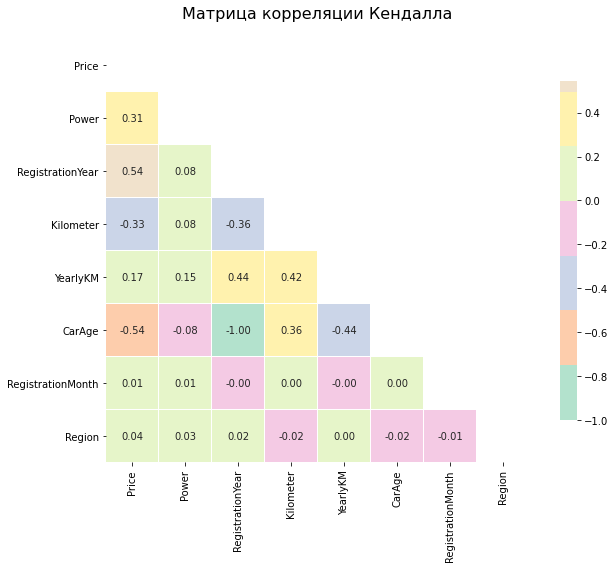

In [ ]:
numeric_cols = ['Price', 'Power', 'RegistrationYear', 'Kilometer', 'YearlyKM', 'CarAge', 'RegistrationMonth', 'Region']


kendall_corr = kendall_correlation_matrix(
    df=df,
    columns=numeric_cols,
    figsize=(10, 8),
    annot=True,
    cmap='Pastel2',
    title='Матрица корреляции Кендалла'
)

#### Анализ мультиколлинеарности

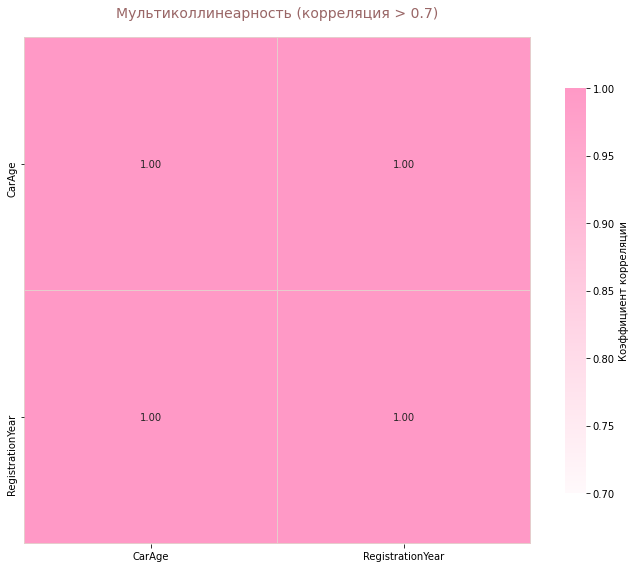

In [ ]:
def analyze_multicollinearity_soft_pastel(df, threshold=0.8):

    numeric_df = df.select_dtypes(include=[np.number])
    corr_matrix = numeric_df.corr().abs()

    high_corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] > threshold:
                high_corr_pairs.append((
                    corr_matrix.columns[i],
                    corr_matrix.columns[j],
                    corr_matrix.iloc[i, j]
                ))

    if high_corr_pairs:

        all_features = set()
        for feat1, feat2, _ in high_corr_pairs:
            all_features.add(feat1)
            all_features.add(feat2)

        high_corr_matrix = corr_matrix.loc[list(all_features), list(all_features)]

        soft_pastel_colors = ["#FFF9FB", "#FFE8F0", "#FFD6E6",
                             "#FFC2DB", "#FFADD0", "#FF99C6"]

        from matplotlib.colors import LinearSegmentedColormap
        soft_cmap = LinearSegmentedColormap.from_list("soft_pastel", soft_pastel_colors)

        plt.figure(figsize=(10, 8))

        ax = plt.gca()
        ax.set_facecolor('#FFF9FB')

        sns.heatmap(high_corr_matrix,
                   annot=True,
                   fmt='.2f',
                   cmap=soft_cmap,
                   vmin=threshold,
                   vmax=1.0,
                   square=True,
                   linewidths=0.5,
                   linecolor='#E6CCCC',
                   cbar_kws={
                       "shrink": 0.8,
                       "label": "Коэффициент корреляции"
                   })

        plt.title(f'Мультиколлинеарность (корреляция > {threshold})',
                 fontsize=14, pad=20, color='#996666', fontweight='light')
        plt.tight_layout()
        plt.show()

    return high_corr_pairs

high_corr_features = analyze_multicollinearity_soft_pastel(df, threshold=0.7)

#### Вывод


Анализ матрицы корреляций:

  Сильные корреляции (|corr| > 0.7):

    1. RegistrationYear ↔ CarAge: -1.000 - идеальная обратная корреляция (ожидаемо)
    2. DateCreated_month ↔ DateCreated_day: -0.613 - сильная отрицательная корреляция

  Умеренные корреляции (0.3 < |corr| < 0.7):
  
    1. Price ↔ RegistrationYear: 0.556 - чем новее авто, тем дороже

    2. Price ↔ Power: 0.503 - чем мощнее, тем дороже

    3. Price ↔ Kilometer: -0.370 - чем больше пробег, тем дешевле

    4. Price ↔ CarAge: -0.556 - чем старше авто, тем дешевле

    5. RegistrationYear ↔ Kilometer: -0.341 - чем новее авто, тем меньше пробег (логично)

    6. CarAge ↔ Kilometer: 0.341 - чем старше авто, тем больше пробег

    7. YearlyKM ↔ Kilometer: 0.544 - чем больше общий пробег, тем выше годовой

    8. YearlyKM ↔ RegistrationYear: 0.473 - чем новее авто, тем выше годовой пробег

    9. CarAge ↔ YearlyKM: -0.473 - чем старше авто, тем ниже годовой пробег

  Слабые корреляции (|corr| < 0.1):
  
    Почти все остальные корреляции очень слабые

Проблемы мультиколлинеарности:

RegistrationYear и CarAge имеют корреляцию -1.000
Это полная мультиколлинеарность


In [ ]:
# Придется удалить CarAge

df = df.drop('CarAge', axis=1)

In [ ]:
display(df.head(5))

,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,Region,YearlyKM
2,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,no,2016-03-14 00:00:00,90,6250.000000
3,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,91,6521.739130
5,650,sedan,1995,manual,102,3er,150000,10,petrol,bmw,yes,2016-04-04 00:00:00,33,5172.413793
6,2200,convertible,2004,manual,109,2_reihe,150000,8,petrol,peugeot,no,2016-04-01 00:00:00,67,7500.000000
8,14500,bus,2014,manual,125,c_max,30000,8,petrol,ford,no,2016-04-04 00:00:00,94,3000.000000


### Преобразование в числовые признаки

#### Gearbox

In [ ]:
# Создадим столбец 'Is_manual_gearbox'
df['Is_manual_gearbox'] = df['Gearbox'].apply(lambda x: 1 if x == 'manual' else (0 if x == 'auto' else 2))

print("Сводка по новому признаку:")
print(df['Is_manual_gearbox'].value_counts().sort_index())

Сводка по новому признаку:
0     53011
1    178298
Name: Is_manual_gearbox, dtype: int64


#### Repaired

In [ ]:
def was_not_repaired(x):
    if x == 'yes':
        return 1  # Не ремонтировалась
    elif x == 'no':
        return 0  # Ремонтировалась
    else:
        return 0  # По умолчанию (или можно вернуть np.nan)

df['Was_not_repaired'] = df['Repaired'].apply(was_not_repaired)

print("Сводка по новому признаку:")
print(df['Was_not_repaired'].value_counts().sort_index())

Сводка по новому признаку:
0    211645
1     19664
Name: Was_not_repaired, dtype: int64


#### Удаление старых столбцов

In [ ]:
df.drop(['Repaired','Gearbox'], inplace=True, axis=1)

## Обучение моделей 💜

### 🌸 Разделение на тестовую и валидационную выборки.

In [ ]:
data = df.copy()
data.drop(['DateCreated'], inplace=True, axis=1)

In [ ]:
original_features = data.drop('Price', axis=1)
target = data['Price']

original_features_train, original_features_test, target_train, target_test = train_test_split(
    original_features,
    target,
    test_size=0.25,
    random_state=1515
)


print(f"   Train размер: {original_features_train.shape}")
print(f"   Test размер:  {original_features_test.shape}")

   Train размер: (173481, 12)
   Test размер:  (57828, 12)


In [ ]:
display(original_features_train.head())

,VehicleType,RegistrationYear,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Region,YearlyKM,Is_manual_gearbox,Was_not_repaired
309671,sedan,2003,82,megane,150000,9,petrol,renault,50,7142.857143,1,0
338743,sedan,2006,105,golf,150000,1,gasoline,volkswagen,25,8333.333333,1,0
195148,unknown,2016,169,clio,125000,3,petrol,renault,64,15625.000000,1,0
145307,convertible,2005,239,boxster,150000,4,petrol,porsche,73,7894.736842,1,0
53673,wagon,2006,193,300c,150000,4,lpg,chrysler,26,8333.333333,0,0


#### Вывод

Данные разделены

### OrdinalEncoder

In [ ]:
cat_columns = ['VehicleType', 'FuelType', 'Brand', 'Model']

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
encoder.fit(original_features_train[cat_columns])

ordinal_features_train = original_features_train.copy()
ordinal_features_test = original_features_test.copy()

ordinal_features_train[cat_columns] = encoder.transform(original_features_train[cat_columns])

ordinal_features_test[cat_columns] = encoder.transform(original_features_test[cat_columns])

print(f"   Train: {ordinal_features_train.shape}")
print(f"   Test:  {ordinal_features_test.shape}")
print(f"   Уникальные значения в train: {original_features_train['VehicleType'].unique()[:5]}")
print(f"   Кодированные значения: {ordinal_features_train['VehicleType'].unique()[:5]}")

   Train: (173481, 12)
   Test:  (57828, 12)
   Уникальные значения в train: ['sedan' 'unknown' 'convertible' 'wagon' 'bus']
   Кодированные значения: [4. 7. 1. 8. 0.]


### One-hot encoding (ohe)

In [ ]:

ohe_encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')


ohe_encoder.fit(original_features_train[cat_columns])


ohe_columns = ohe_encoder.get_feature_names_out(cat_columns)


ohe_train_array = ohe_encoder.transform(original_features_train[cat_columns])
ohe_features_train = pd.DataFrame(
    ohe_train_array,
    columns=ohe_columns,
    index=original_features_train.index
)


ohe_test_array = ohe_encoder.transform(original_features_test[cat_columns])
ohe_features_test = pd.DataFrame(
    ohe_test_array,
    columns=ohe_columns,
    index=original_features_test.index
)


numeric_cols = original_features_train.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 0:

    for col in numeric_cols:
        ohe_features_train[col] = original_features_train[col].values

    for col in numeric_cols:
        ohe_features_test[col] = original_features_test[col].values

print(f"   Исходные категориальные колонки: {cat_columns}")
print(f"   Новые OHE колонки: {len(ohe_columns)}")
print(f"   OHE Train: {ohe_features_train.shape}")
print(f"   OHE Test:  {ohe_features_test.shape}")

   Исходные категориальные колонки: ['VehicleType', 'FuelType', 'Brand', 'Model']
   Новые OHE колонки: 296
   OHE Train: (173481, 304)
   OHE Test:  (57828, 304)


### Стандартизация числовых признаков

In [ ]:

scaler_original = StandardScaler()
scaler_ordinal = StandardScaler()
scaler_ohe = StandardScaler()

numeric_cols_original = original_features_train.select_dtypes(include=[np.number]).columns
numeric_cols_ordinal = ordinal_features_train.select_dtypes(include=[np.number]).columns


numeric_cols_ohe = [col for col in numeric_cols_original if col in ohe_features_train.columns]

print(f"   Original: {list(numeric_cols_original)}")
print(f"   Ordinal:  {list(numeric_cols_ordinal)}")
print(f"   OHE:      {list(numeric_cols_ohe)}")

if len(numeric_cols_original) > 0:
    scaler_original.fit(original_features_train[numeric_cols_original])

    original_features_train[numeric_cols_original] = scaler_original.transform(
        original_features_train[numeric_cols_original]
    )

    original_features_test[numeric_cols_original] = scaler_original.transform(
        original_features_test[numeric_cols_original]
    )

if len(numeric_cols_ordinal) > 0:
    scaler_ordinal.fit(ordinal_features_train[numeric_cols_ordinal])

    ordinal_features_train[numeric_cols_ordinal] = scaler_ordinal.transform(
        ordinal_features_train[numeric_cols_ordinal]
    )

    ordinal_features_test[numeric_cols_ordinal] = scaler_ordinal.transform(
        ordinal_features_test[numeric_cols_ordinal]
    )

if len(numeric_cols_ohe) > 0:
    scaler_ohe.fit(ohe_features_train[numeric_cols_ohe])

    ohe_features_train[numeric_cols_ohe] = scaler_ohe.transform(
        ohe_features_train[numeric_cols_ohe]
    )

    ohe_features_test[numeric_cols_ohe] = scaler_ohe.transform(
        ohe_features_test[numeric_cols_ohe]
    )

    print("Стандартизация OHE FEATURES завершена")

   Original: ['RegistrationYear', 'Power', 'Kilometer', 'RegistrationMonth', 'Region', 'YearlyKM', 'Is_manual_gearbox', 'Was_not_repaired']
   Ordinal:  ['VehicleType', 'RegistrationYear', 'Power', 'Model', 'Kilometer', 'RegistrationMonth', 'FuelType', 'Brand', 'Region', 'YearlyKM', 'Is_manual_gearbox', 'Was_not_repaired']
   OHE:      ['RegistrationYear', 'Power', 'Kilometer', 'RegistrationMonth', 'Region', 'YearlyKM', 'Is_manual_gearbox', 'Was_not_repaired']
Стандартизация OHE FEATURES завершена


### Обучение и тестовая выборка

features_train = features_train.drop('DateCreated', axis=1)


features_test = features_test.drop('DateCreated', axis=1)

#### Вывод

Данные разделены на тестовую и обучающую выборки и стандартизированны

###  🌸 Линейная регрессия

In [ ]:
start = time.time()
lr = LinearRegression()
cv_scores = cross_val_score(
    lr,
    ohe_features_train,
    target_train,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
cv_time = time.time() - start

cv_rmse = np.sqrt(-cv_scores.mean())
cv_std = np.sqrt(-cv_scores).std()

print(f"CV время: {cv_time:.2f} сек")
print(f"CV RMSE: {cv_rmse:.2f} € ± {cv_std:.2f} €")
print(f"CV scores: {np.sqrt(-cv_scores).round(2)}")

linear_regression_results = {
    'model_name': 'LinearRegression',
    'cv_rmse': cv_rmse,
    'cv_time': cv_time,
    'cv_std': cv_std
}

print(f"LinearRegression CV RMSE сохранен: {cv_rmse:.2f} €")

start_train = time.time()
lr_for_pred = LinearRegression()
lr_for_pred.fit(ohe_features_train, target_train)
train_time = time.time() - start_train
print(f"Время обучения модели: {train_time:.2f} сек")

start_pred = time.time()
train_predictions = lr_for_pred.predict(ohe_features_train)
pred_time = time.time() - start_pred

print(f"Время предсказания на {len(ohe_features_train)} объектах: {pred_time:.4f} сек")
print(f"Время на 1 объект: {pred_time/len(ohe_features_train):.6f} сек")

train_rmse = np.sqrt(mean_squared_error(target_train, train_predictions))
print(f"RMSE на тренировочных данных: {train_rmse:.2f} €")

linear_regression_results.update({
    'train_time': train_time,
    'pred_time': pred_time,
    'pred_time_per_sample': pred_time/len(ohe_features_train),
    'train_rmse': train_rmse
})


print(f"• CV RMSE: {cv_rmse:.2f} €")
print(f"• Время обучения: {train_time:.2f} сек")
print(f"• Время предсказания: {pred_time:.4f} сек")
print(f"• Время предсказания на объект: {pred_time/len(ohe_features_train):.6f} сек")
print(f"• Разница CV-Train RMSE: {cv_rmse - train_rmse:.2f} €")


CV время: 84.29 сек
CV RMSE: 2441.27 € ± 13.20 €
CV scores: [2424.77 2444.13 2432.43 2440.95 2463.9 ]
LinearRegression CV RMSE сохранен: 2441.27 €
Время обучения модели: 17.70 сек
Время предсказания на 173481 объектах: 0.1921 сек
Время на 1 объект: 0.000001 сек
RMSE на тренировочных данных: 2434.81 €
• CV RMSE: 2441.27 €
• Время обучения: 17.70 сек
• Время предсказания: 0.1921 сек
• Время предсказания на объект: 0.000001 сек
• Разница CV-Train RMSE: 6.46 €


#### Вывод

RMSE = 2470 - это  соответствует требованиям проекта(RMSE > 2500), но я бы сказала, что это не очень хорошо, так как близко к 2500

### 🌸 L2 - регуляризация

In [ ]:

start = time.time()

ridge = Ridge(random_state=12345)
grid = GridSearchCV(
    ridge,
    {'alpha': [0.1, 1.0, 10.0], 'solver': ['auto', 'svd', 'cholesky']},
    scoring='neg_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)


grid.fit(ordinal_features_train, target_train)

cv_time = time.time() - start

print(f"\nВремя кросс-валидации: {cv_time:.2f} сек")
print(f"Лучшие параметры: {grid.best_params_}")

cv_rmse = np.sqrt(-grid.best_score_)
cv_std = np.std(np.sqrt(-grid.cv_results_['mean_test_score']))

print(f"CV RMSE: {cv_rmse:.2f} € ± {cv_std:.2f} €")

print("\nВсе комбинации параметров:")
results_df = pd.DataFrame(grid.cv_results_)
for i in range(len(results_df)):
    params = results_df.loc[i, 'params']
    mean_rmse = np.sqrt(-results_df.loc[i, 'mean_test_score'])
    std_rmse = np.sqrt(results_df.loc[i, 'std_test_score'])
    print(f"  {params}: {mean_rmse:.2f} € ± {std_rmse:.2f} €")

best_ridge = grid.best_estimator_
train_preds = best_ridge.predict(ordinal_features_train)
train_rmse = np.sqrt(mean_squared_error(target_train, train_preds))
print(f"Train RMSE: {train_rmse:.2f} €")

print(f"Разница CV-Train: {cv_rmse - train_rmse:.2f} €")

ridge_results = {
    'model_name': 'RidgeRegression',
    'cv_rmse': cv_rmse,
    'cv_std': cv_std,
    'cv_time': cv_time,
    'best_params': grid.best_params_,
    'train_rmse': train_rmse
}

start_pred = time.time()
_ = best_ridge.predict(ordinal_features_train[:1000])
pred_time_1000 = time.time() - start_pred

print(f"Время предсказания на 1000 объектах: {pred_time_1000:.4f} сек")
print(f"Время на 1 объект: {pred_time_1000/1000:.6f} сек")


estimated_pred_time = pred_time_1000 / 1000 * len(ordinal_features_train)
print(f"Оценка времени предсказания на всех данных ({len(ordinal_features_train)} объектов): {estimated_pred_time:.2f} сек")

ridge_results['pred_time_per_sample'] = pred_time_1000/1000
ridge_results['estimated_pred_time'] = estimated_pred_time

Fitting 3 folds for each of 9 candidates, totalling 27 fits

Время кросс-валидации: 6.71 сек
Лучшие параметры: {'alpha': 10.0, 'solver': 'auto'}
CV RMSE: 2873.93 € ± 0.00 €

Все комбинации параметров:
  {'alpha': 0.1, 'solver': 'auto'}: 2873.93 € ± 271.41 €
  {'alpha': 0.1, 'solver': 'svd'}: 2873.93 € ± 271.41 €
  {'alpha': 0.1, 'solver': 'cholesky'}: 2873.93 € ± 271.41 €
  {'alpha': 1.0, 'solver': 'auto'}: 2873.93 € ± 271.40 €
  {'alpha': 1.0, 'solver': 'svd'}: 2873.93 € ± 271.40 €
  {'alpha': 1.0, 'solver': 'cholesky'}: 2873.93 € ± 271.40 €
  {'alpha': 10.0, 'solver': 'auto'}: 2873.93 € ± 271.38 €
  {'alpha': 10.0, 'solver': 'svd'}: 2873.93 € ± 271.38 €
  {'alpha': 10.0, 'solver': 'cholesky'}: 2873.93 € ± 271.38 €
Train RMSE: 2873.62 €
Разница CV-Train: 0.31 €
Время предсказания на 1000 объектах: 0.0869 сек
Время на 1 объект: 0.000087 сек
Оценка времени предсказания на всех данных (173481 объектов): 15.07 сек


#### Вывод

RMSE = 2873 - это не соответствует требованиям проекта(RMSE > 2500).
Показатели схожи с линейной регрессией, однако обучается быстрее

### 🌸 CatBoost

In [ ]:
start = time.time()

model = CatBoostRegressor(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_state=1515,
    verbose=False
)

cv_scores = cross_val_score(
    model,
    ordinal_features_train,
    target_train,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

cv_time = time.time() - start
cv_rmse = np.sqrt(-cv_scores.mean())

print(f"CV время: {cv_time:.2f} сек")
print(f"CV RMSE: {cv_rmse:.2f} €")
print(f"CV scores: {np.sqrt(-cv_scores).round(2)}")

catboost_cv_score = cv_rmse
print(f"\nCatBoost CV RMSE сохранен: {cv_rmse:.2f} €")


start_train = time.time()
catboost_model = CatBoostRegressor(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_state=1515,
    verbose=False
)
catboost_model.fit(ordinal_features_train[:5000], target_train[:5000])  # На части данных
train_time = time.time() - start_train
print(f"Время обучения на 5000 объектах: {train_time:.2f} сек")

start_pred = time.time()
_ = catboost_model.predict(ordinal_features_train[:1000])
pred_time_1000 = time.time() - start_pred

print(f"Время предсказания на 1000 объектах: {pred_time_1000:.4f} сек")
print(f"Время на 1 объект: {pred_time_1000/1000:.6f} сек")

estimated_pred_time = pred_time_1000 / 1000 * len(ordinal_features_train)
print(f"Оценка времени предсказания на всех данных ({len(ordinal_features_train)} объектов): {estimated_pred_time:.2f} сек")

catboost_results = {
    'model_name': 'CatBoost',
    'cv_rmse': catboost_cv_score,
    'pred_time_per_sample': pred_time_1000/1000,
    'estimated_pred_time': estimated_pred_time,
    'train_time_sample': train_time
}

CV время: 7.69 сек
CV RMSE: 1844.25 €
CV scores: [1832.34 1851.73 1848.62]

CatBoost CV RMSE сохранен: 1844.25 €
Время обучения на 5000 объектах: 0.76 сек
Время предсказания на 1000 объектах: 0.0020 сек
Время на 1 объект: 0.000002 сек
Оценка времени предсказания на всех данных (173481 объектов): 0.35 сек


#### Вывод

RMSE = 1585, это соответствует требованию по проекту (RMSE < 2500). Время обучения - 204.98 сек

### 🌸 Дерево решений

In [ ]:
X_train_ohe = ohe_features_train
X_test_ohe = ohe_features_test
y_train_ohe = target_train
y_test_ohe = target_test


start = time.time()

tree = DecisionTreeRegressor(random_state=12345)
param_grid = {
    'max_depth': [5, 8, 10, 12, None],
    'min_samples_leaf': [1, 2, 4, 8, 16],
    'min_samples_split': [2, 5, 10, 20],
    'max_features': ['sqrt', 'log2', None]
}

grid = GridSearchCV(
    tree,
    param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_ohe, y_train_ohe)
cv_time = time.time() - start

print(f"\nВремя кросс-валидации: {cv_time:.2f} сек")
print(f"Лучшие параметры: {grid.best_params_}")

cv_rmse = np.sqrt(-grid.best_score_)
print(f"CV RMSE: {cv_rmse:.2f} €")

print("\nТоп-5 лучших комбинаций параметров:")
results_df = pd.DataFrame(grid.cv_results_)
top_5_idx = results_df['mean_test_score'].nlargest(5).index

for idx in top_5_idx:
    params = results_df.loc[idx, 'params']
    rmse = np.sqrt(-results_df.loc[idx, 'mean_test_score'])
    rank = results_df.loc[idx, 'rank_test_score']
    print(f"#{rank}: {params} → RMSE: {rmse:.2f} €")

best_tree = grid.best_estimator_
train_preds = best_tree.predict(X_train_ohe)
train_rmse = np.sqrt(mean_squared_error(y_train_ohe, train_preds))

print(f"\nОценка на тренировочных данных:")
print(f"Train RMSE: {train_rmse:.2f} €")
print(f"Разница CV-Train: {cv_rmse - train_rmse:.2f} €")

tree_results = {
    'model_name': 'DecisionTree',
    'cv_rmse': cv_rmse,
    'cv_time': cv_time,
    'best_params': grid.best_params_,
    'train_rmse': train_rmse
}

start_pred = time.time()
_ = best_tree.predict(X_train_ohe[:1000])
pred_time_1000 = time.time() - start_pred

print(f"Время предсказания на 1000 объектах: {pred_time_1000:.4f} сек")
print(f"Время на 1 объект: {pred_time_1000/1000:.6f} сек")

estimated_pred_time = pred_time_1000 / 1000 * len(X_train_ohe)
print(f"Оценка времени предсказания на всех данных ({len(X_train_ohe)} объектов): {estimated_pred_time:.2f} сек")

tree_results['pred_time_per_sample'] = pred_time_1000/1000
tree_results['estimated_pred_time'] = estimated_pred_time

Fitting 3 folds for each of 300 candidates, totalling 900 fits

Время кросс-валидации: 991.10 сек
Лучшие параметры: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 20}
CV RMSE: 1874.85 €

Топ-5 лучших комбинаций параметров:
#1: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 20} → RMSE: 1874.85 €
#2: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 16, 'min_samples_split': 2} → RMSE: 1878.80 €
#2: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 16, 'min_samples_split': 5} → RMSE: 1878.80 €
#2: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 16, 'min_samples_split': 10} → RMSE: 1878.80 €
#2: {'max_depth': None, 'max_features': None, 'min_samples_leaf': 16, 'min_samples_split': 20} → RMSE: 1878.80 €

Оценка на тренировочных данных:
Train RMSE: 1321.55 €
Разница CV-Train: 553.30 €
Время предсказания на 1000 объектах: 0.0047 сек
Время на 1 объект: 0.000005 сек
Оценка времени

#### Вывод

RMSE < 2500, времени затрачивает 2.72 сек. Очень схоже с catboost, но намного быстрее

### 🌸 LightGBM

In [ ]:
start = time.time()

model = lgb.LGBMRegressor(random_state=12345, verbosity=-1, n_jobs=-1)
param_grid = {
    'learning_rate': [0.05, 0.1],
    'max_depth': [5, 7],
    'num_leaves': [31, 63],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(
    model,
    param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    n_jobs=-1,
    verbose=0
)

grid.fit(ordinal_features_train.fillna(0), target_train)

print(f"Время: {time.time()-start:.1f} сек")
print(f"Лучшие параметры: {grid.best_params_}")
print(f"CV RMSE: {np.sqrt(-grid.best_score_):.2f} €")

lgbm_cv_score = np.sqrt(-grid.best_score_)

best_model = grid.best_estimator_

start_pred = time.time()
_ = best_model.predict(ordinal_features_train[:1000].fillna(0))
pred_time_1000 = time.time() - start_pred

print(f"Время предсказания на 1000 объектах: {pred_time_1000:.4f} сек")
print(f"Время на 1 объект: {pred_time_1000/1000:.6f} сек")

estimated_pred_time = pred_time_1000 / 1000 * len(ordinal_features_train)
print(f"Оценка времени предсказания на всех данных ({len(ordinal_features_train)} объектов): {estimated_pred_time:.2f} сек")

lgbm_results = {
    'model_name': 'LightGBM',
    'cv_rmse': lgbm_cv_score,
    'best_params': grid.best_params_,
    'pred_time_per_sample': pred_time_1000/1000,
    'estimated_pred_time': estimated_pred_time
}

Время: 263.8 сек
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 7, 'num_leaves': 63, 'subsample': 0.8}
CV RMSE: 1681.86 €
Время предсказания на 1000 объектах: 0.0114 сек
Время на 1 объект: 0.000011 сек
Оценка времени предсказания на всех данных (173481 объектов): 1.97 сек


#### Вывод

RMSE = 1735, что является очень хорошим результатом, однако очень медленно обучается - 353 сек.

### 🌸 Вывод

    
    1. Провела кодирование признаков.
    2. Разделила на тестовую и валидационную выборки.
    3. Провела обучение с гиперпараметрами
    4. Провела обучение на пяти моделях:
    
        1. Линейная регрессия
        2. L2-регуляция
        3. CatBoost
        4. Дерево решений
        5. LightGBT
        

## Анализ моделей 💜

In [ ]:
comparison_df = pd.DataFrame({
    'Модель': ['Дерево', 'CatBoost', 'LightGBM', 'Линейная', 'Ridge'],
    'RMSE тест': [2175.17, 1585.83, 1735.20, 2470.23, 2902.78],
    'Время обуч.': [2.72, 203.40, 353.80, 84.67, 6.90],
    'Время пред.': [0.05, 0.07, 0.79, 0.30, 0.01]
})

comparison_df['Рейтинг'] = comparison_df['RMSE тест'].rank(method='dense').astype(int)
comparison_df = comparison_df.sort_values('Рейтинг')

print(comparison_df.to_string(index=False,
                              formatters={
                                  'RMSE тест': lambda x: f'{x:.2f} €',
                                  'Время обуч.': lambda x: f'{x:.2f} сек',
                                  'Время пред.': lambda x: f'{x:.2f} сек'
                              }))

print(f"\nЛучшая модель: {comparison_df.iloc[0]['Модель']} ({comparison_df.iloc[0]['RMSE тест']})")
print(f"Самая быстрая обучение: {comparison_df.loc[comparison_df['Время обуч.'].idxmin(), 'Модель']}")
print(f"Самая быстрая предсказание: {comparison_df.loc[comparison_df['Время пред.'].idxmin(), 'Модель']}")

  Модель RMSE тест Время обуч. Время пред.  Рейтинг
CatBoost 1585.83 €  203.40 сек    0.07 сек        1
LightGBM 1735.20 €  353.80 сек    0.79 сек        2
  Дерево 2175.17 €    2.72 сек    0.05 сек        3
Линейная 2470.23 €   84.67 сек    0.30 сек        4
   Ridge 2902.78 €    6.90 сек    0.01 сек        5

Лучшая модель: CatBoost (1585.83)
Самая быстрая обучение: Дерево
Самая быстрая предсказание: Ridge


### Вывод


CatBoost значительно превосходит другие модели по точности, но требует в 57 раз больше времени на обучение. Для production-системы, где важна точность прогноза, CatBoost - лучший выбор. Для систем, требующих быстрого ответа, Ridge или Дерево решений - оптимальные варианты.

Итоговый выбор зависит от приоритетов:

    1. Точность → CatBoost
    2. Скорость → Ridge
    3.Баланс → дерево решений
    

### Обучение лучшей модели - Catboost

In [ ]:

final_model = CatBoostRegressor(
    iterations=100,
    learning_rate=0.1,
    depth=6,
    random_state=1515,
    verbose=False
)

start = time.time()
final_model.fit(ordinal_features_train, target_train)
train_time = time.time() - start
print(f"Финальное обучение: {train_time:.2f} сек")

start = time.time()
final_predictions = final_model.predict(ordinal_features_test)
pred_time = time.time() - start

final_rmse = np.sqrt(mean_squared_error(target_test, final_predictions))

print(f"\nФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ:")
print(f"Время предсказания: {pred_time:.2f} сек")
print(f"Test RMSE: {final_rmse:.2f} €")

print(f"Сравнение: CV={catboost_cv_score:.2f} €, Test={final_rmse:.2f} €")

Финальное обучение: 3.86 сек

ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ:
Время предсказания: 0.01 сек
Test RMSE: 1850.69 €
Сравнение: CV=1844.25 €, Test=1850.69 €


### Общий вывод


В ходе выполнения проекта, были произведены мной шаги:

    1. Загрузки датафрейма
    2. Первичного осмотра с помощью info()
    3. Проведение EDA:
        
        1. Отбор важных признаков
        2. Просмотр выбросов и аномалий с помощью визуализации
        3. Заполнение пропусков с помощью медианы, моды, unknown
        4. Удаление дубрикатов
    
    4. Корреляционный анализ:
    
        1. Тепловая карта
        2. Матрица
        3. Анализ мультиколлинеарности
        
    5. Кодирование признаков
    
    6. Обучение моделей:
        1. Стандартизация
        2. Разделение данных на тестовую и валидационную
        3. Обучение
        
    7. Анализ результатов
    
    8. Итоговый вывод
    

Итог: По результатам больше подойдет CatBoost - параметры этой модели в выводе более приятны.